In [1]:
from bauer.models import RiskModel
import numpy as np
import pandas as pd

In [114]:
parameters = {'risky_prior_mu':np.log(50), 'risky_prior_std':1.0, 'safe_prior_mu':np.log(14), 'safe_prior_std':2.0, 'n1_evidence_sd':0.4, 'n2_evidence_sd':0.2}


n_safe = [5., 7., 10, 14, 20, 28]
risky_p = 0.55

fractions = np.exp(np.linspace(np.log(0.25), np.log(4), 8, True))
risky_first = [True, False]

paradigm = pd.MultiIndex.from_product([n_safe, fractions, risky_first], names=['n_safe', 'fraction', 'risky_first']).to_frame(index=False)

paradigm['n1'] = np.round(paradigm['fraction'] * paradigm['n_safe']).where(paradigm['risky_first'], paradigm['n_safe'])
paradigm['n2'] = np.round(paradigm['fraction'] * paradigm['n_safe']).where(~paradigm['risky_first'], paradigm['n_safe'])

paradigm['p1'] = np.where(paradigm['risky_first'], risky_p, 1.)
paradigm['p2'] = np.where(paradigm['risky_first'], 1., risky_p)


model = RiskModel(fit_seperate_evidence_sd=True, prior_estimate='full')


df = model.simulate(paradigm, parameters, n_samples=4)
df['choice'] = df['simulated_choice']
df['n_risky'] = df['n1'].where(df['risky_first'], df['n2'])
df['n_safe'] = df['n2'].where(df['risky_first'], df['n1'])

df['log(risky/safe)'] = np.log(df['n_risky']) - np.log(df['n_safe'])
df['chose_risky'] = df['choice'].where(~df['risky_first'], ~df['choice'])
df['log(fraction)'] = np.log(df['fraction'])

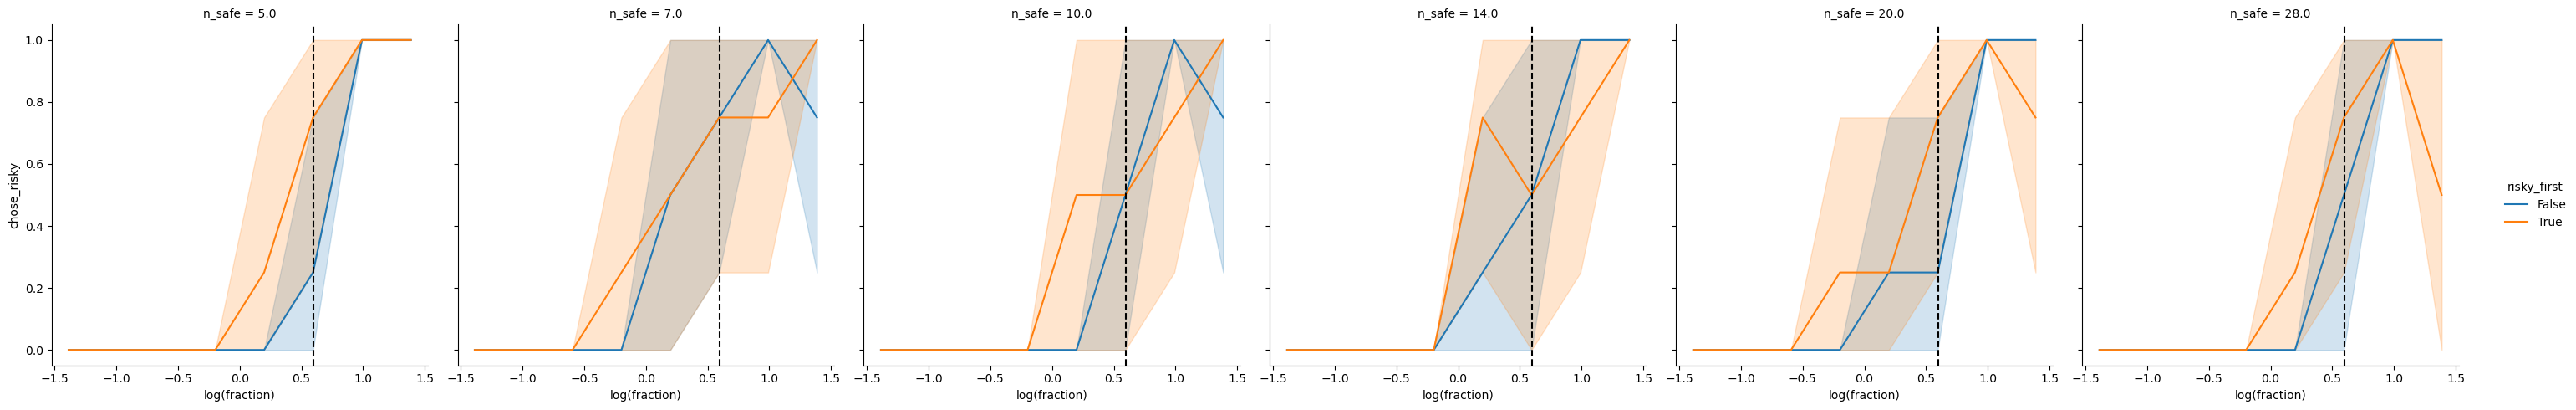

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.relplot(data=df.reset_index(), x='log(fraction)', y='chose_risky', hue='risky_first', kind='line', col='n_safe')

g.map(plt.axvline, x=np.log(1./.55), c='k', ls='--')

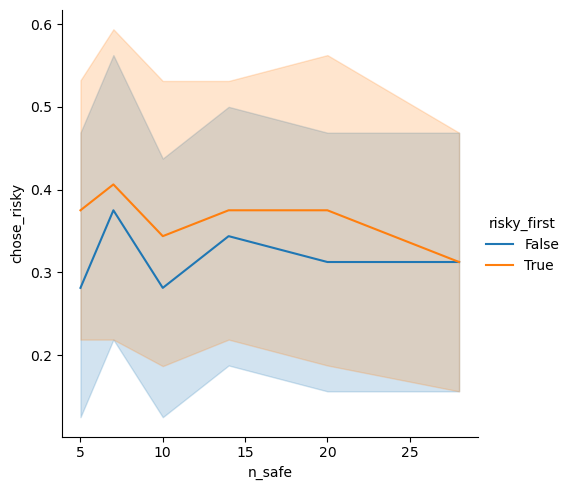

In [4]:
sns.relplot(x='n_safe', y='chose_risky', data=df.reset_index(), kind='line', hue='risky_first')

In [5]:
model.build_estimation_model(df, hierarchical=False)

In [6]:
model.fit_map()

{'n1_evidence_sd': array(0.41040799),
 'n2_evidence_sd': array(0.24552012),
 'risky_prior_mu': array(3.58100895),
 'risky_prior_std': array(1.90849382),
 'safe_prior_mu': array(3.08051983),
 'safe_prior_std': array(2.17708259)}

In [7]:
idata = model.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [n1_evidence_sd_untransformed, n2_evidence_sd_untransformed, risky_prior_mu, risky_prior_std_untransformed, safe_prior_mu, safe_prior_std_untransformed]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 3 seconds.


<Axes: ylabel='Density'>

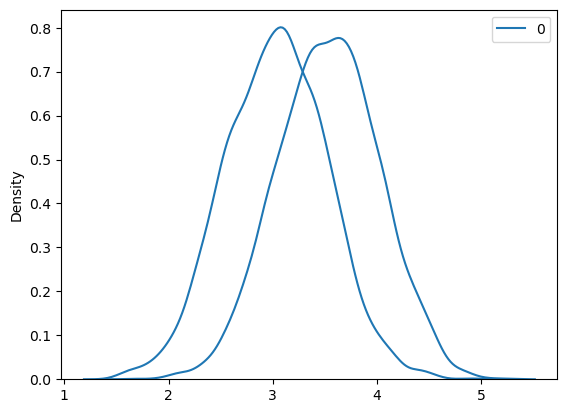

In [8]:
sns.kdeplot(idata.posterior['risky_prior_mu'].to_dataframe().values)
sns.kdeplot(idata.posterior['safe_prior_mu'].to_dataframe().values)

<Axes: ylabel='Density'>

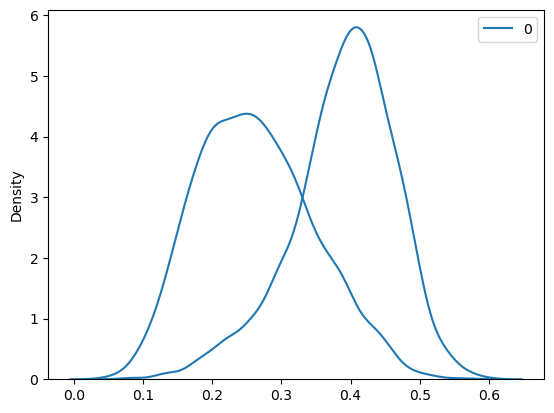

In [9]:
sns.kdeplot(idata.posterior['n1_evidence_sd'].to_dataframe().values)
sns.kdeplot(idata.posterior['n2_evidence_sd'].to_dataframe().values)

In [16]:
gen_pars = model.sample_parameters_from_prior(n_subjects=100)

subjects = gen_pars.index
multi_subject_paradigm = pd.concat([paradigm]*len(subjects), keys=subjects, names=['subject'])


df = model.simulate(multi_subject_paradigm, gen_pars, n_samples=4)
df['choice'] = df['simulated_choice']
df['chose_risky'] = df['choice'].where(df['risky_first'], ~df['choice'])
df['n_safe'] = df['n2'].where(df['risky_first'], df['n1'])

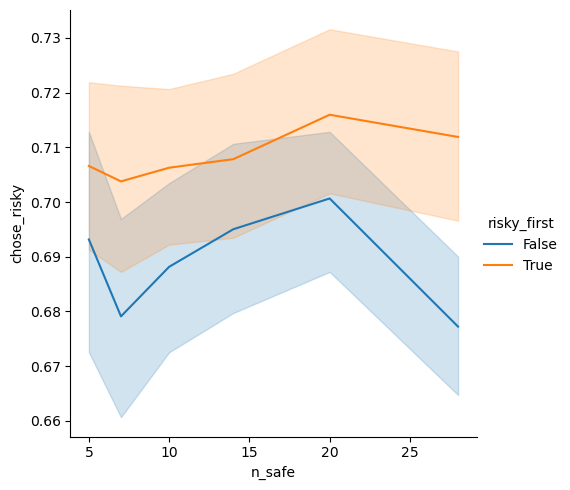

In [18]:
sns.relplot(x='n_safe', y='chose_risky', data=df.groupby(['subject', 'risky_first', 'n_safe']).mean().reset_index(), kind='line', hue='risky_first')

In [19]:
model.build_estimation_model(df, hierarchical=True)

In [20]:
est_pars = model.fit_map()

In [34]:
gen_pars.columns.name = 'parameter'

In [35]:
gen_pars

parameter,n1_evidence_sd,n2_evidence_sd,risky_prior_mu,risky_prior_std,safe_prior_mu,safe_prior_std
subject,,,,,,
1,0.094475,0.330596,2.005710,2.434853,2.887692,3.073799
2,0.300711,0.172688,3.904318,2.761760,2.400262,2.009737
3,0.233206,0.152544,2.843580,2.708766,2.016143,2.053144
4,0.699504,0.181303,3.148070,1.416461,3.002079,0.998896
5,0.383561,0.491776,3.335315,1.559765,3.897663,1.413158
...,...,...,...,...,...,...
96,0.190777,0.758932,4.635776,2.710559,3.741493,2.469388
97,0.320171,0.073673,3.567314,0.968632,4.421907,2.690392
98,0.238892,0.153461,4.067064,2.605165,2.436154,1.518981


In [36]:

est_pars

parameter,n1_evidence_sd,n2_evidence_sd,risky_prior_mu,risky_prior_std,safe_prior_mu,safe_prior_std
1,0.187869,0.240830,3.508350,0.514134,2.905257,0.493850
2,0.198752,0.285324,3.070454,0.514141,2.451069,0.465488
3,0.086784,0.226580,3.250985,0.514014,2.462589,0.377256
4,0.473065,0.332118,3.565418,0.514146,3.049840,0.423982
5,0.412256,0.422939,9.598185,0.514024,10.289513,0.580812
...,...,...,...,...,...,...
96,0.356417,0.367045,6.320695,0.514080,5.735622,0.538440
97,0.179118,0.191178,8.689706,0.513027,16.493143,0.830486
98,0.181568,0.187974,10.108622,0.513951,12.771627,0.633915
99,0.326833,0.426331,3.716114,0.514081,2.792613,0.523346


/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


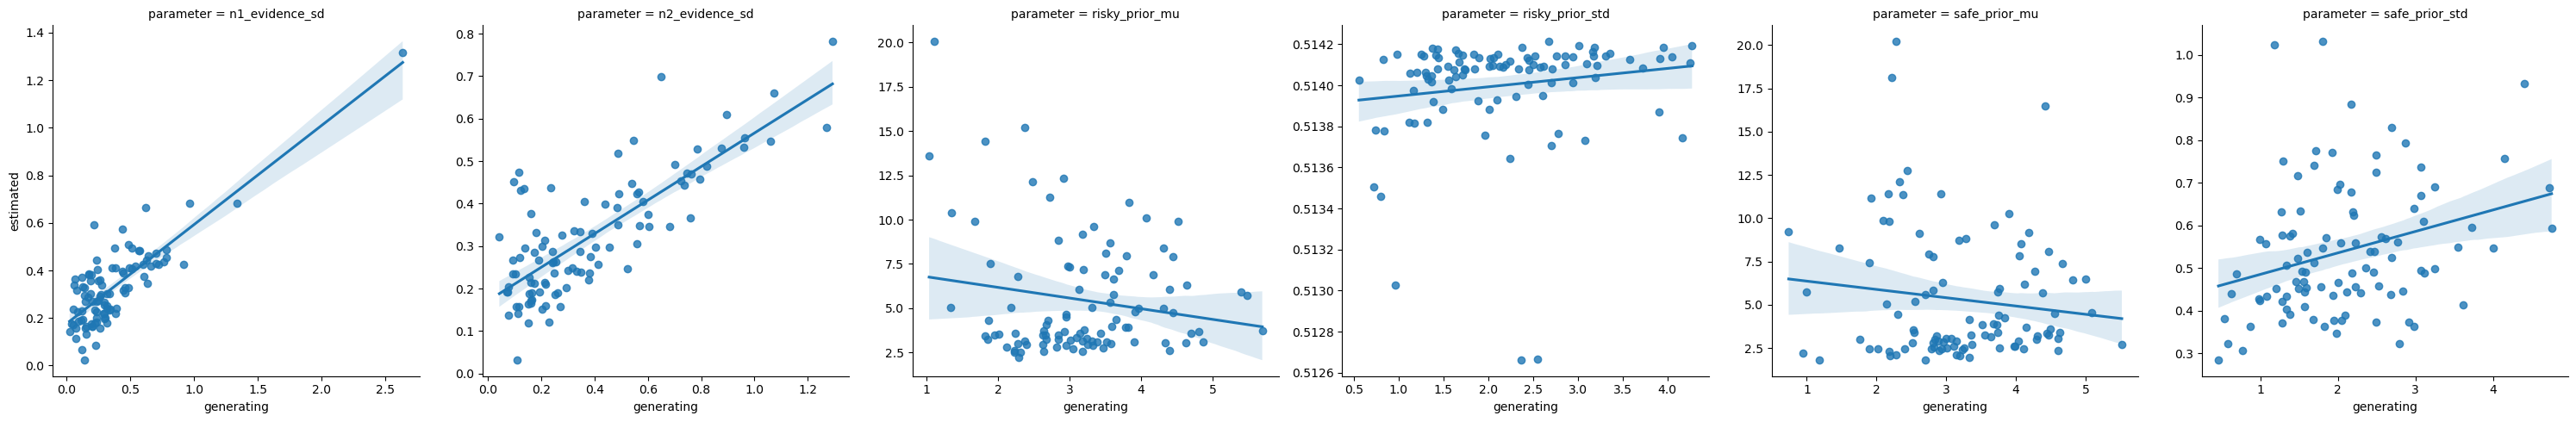

In [40]:
pars = pd.concat((gen_pars, est_pars), keys=['generating', 'estimated'], names=['source'], axis=1)
# pars.columns

sns.lmplot(x='generating', y='estimated', data=pars.stack('parameter').reset_index(), col='parameter', sharex=False, sharey=False)

# pars

In [41]:
idata = model.sample()

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [n1_evidence_sd_mu_untransformed, n1_evidence_sd_sd, n1_evidence_sd_offset, n2_evidence_sd_mu_untransformed, n2_evidence_sd_sd, n2_evidence_sd_offset, risky_prior_mu_mu, risky_prior_mu_sd, risky_prior_mu_offset, risky_prior_std_mu_untransformed, risky_prior_std_sd, risky_prior_std_offset, safe_prior_mu_mu, safe_prior_mu_sd, safe_prior_mu_offset, safe_prior_std_mu_untransformed, safe_prior_std_sd, safe_prior_std_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 855 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


In [45]:
est_pars_post = []
for par in gen_pars.columns:
    est_pars_post.append(idata.posterior[par].to_dataframe().groupby('subject').mean())

est_pars_post = pd.concat(est_pars_post, axis=1)

In [173]:
est_par_post

NameError: name 'est_par_post' is not defined

/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


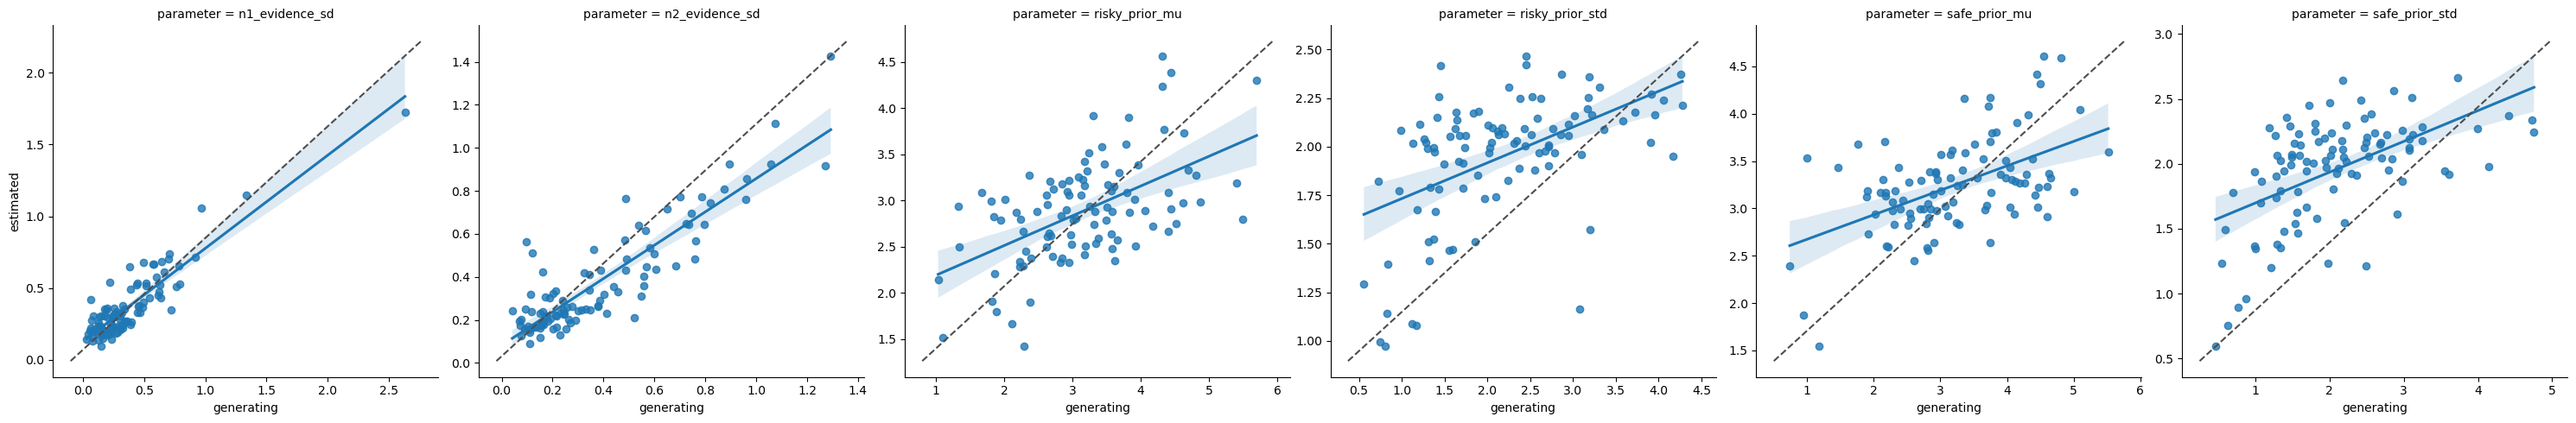

In [48]:
tmp = pd.concat((gen_pars, est_pars_post), keys=['generating', 'estimated'], names=['source'], axis=1)


g = sns.lmplot(x='generating', y='estimated', data=tmp.stack('parameter').reset_index(), col='parameter', sharex=False, sharey=False)

# plot identity line
for ax in g.axes.flat:
    ax.plot(ax.get_xlim(), ax.get_ylim(), ls="--", c=".3")

<Axes: xlabel='source-parameter', ylabel='source-parameter'>

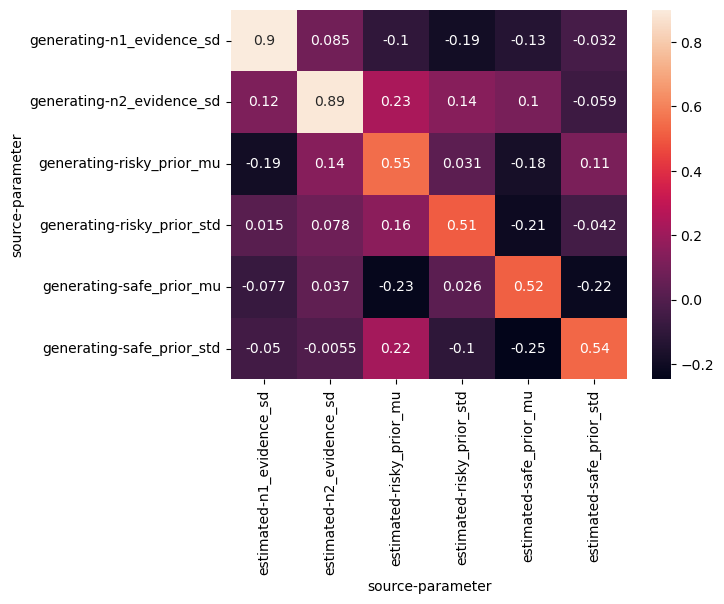

In [53]:
sns.heatmap(tmp.corr().loc[['generating'], ['estimated']], annot=True)

In [55]:
!ls /data/ds-risk/derivatives/cogmodels

figures
gamma_rnp_simple.tsv
model-12_trace.netcdf
model-1_trace.netcdf
model-222_trace.netcdf
model-42_trace.netcdf
model-52_trace.netcdf
model-62_trace.netcdf
model-72_trace.netcdf
model-eu_trace.netcdf
model-neural32_trace.netcdf
model-neural33_null_trace.netcdf
model-neural33_trace.netcdf
model-neural34_trace.netcdf
model-neural35_trace.netcdf
model-neural55_trace.netcdf
model-probit_full_ses-3t2_trace.netcdf
model-probit_full_ses-7t2_trace.netcdf
model-probit_full_session_trace.netcdf
model-probit_neural1072_ses-3t2_trace.netcdf
model-probit_neural1072_ses-7t2_trace.netcdf
model-probit_neural107_ses-3t2_trace.netcdf
model-probit_neural107_ses-7t2_trace.netcdf
model-probit_neural10_ses-3t2_trace.netcdf
model-probit_neural10_ses-7t2_trace.netcdf
model-probit_neural10_trace.netcdf
model-probit_neural1_no_outliers_ses-7t2_trace.netcdf
model-probit_neural1_ses-3t2_trace.netcdf
model-probit_neural1_ses-7t2_trace.netcdf
model-probit_neural2_ses-7t2_trace.netcdf
model-probit_neural3_ses-3

In [69]:
import arviz as az
idata_3t = az.from_netcdf('/data/ds-risk/derivatives/cogmodels/ses-3t2_model-1_trace.netcdf')
idata_7t = az.from_netcdf('/data/ds-risk/derivatives/cogmodels/ses-7t2_model-1_trace.netcdf')
idata_full = az.from_netcdf('/data/ds-risk/derivatives/cogmodels/model-12_trace.netcdf')

In [85]:
model.__format__

In [89]:
idata_full.posterior['risky_prior_mu'].to_dataframe().unstack(level=-1).sum(1)

chain  draw  subject
0      0     02         2.330272
             03         3.795941
             04         2.553297
             05         2.373269
             06         2.898653
                          ...   
3      1499  28         2.595154
             29         3.063073
             30         2.605037
             31         2.877377
             32         2.124938
Length: 180000, dtype: float64

In [132]:
pars_3t

,n1_evidence_sd,n2_evidence_sd,risky_prior_mu,risky_prior_std,safe_prior_mu,safe_prior_std
subject,,,,,,
2,0.304708,0.201287,2.362878,0.755887,0.560088,0.794108
3,0.478257,0.216440,2.554223,0.482152,5.924732,0.519099
4,0.228605,0.201950,2.631292,0.240429,1.414347,0.876417
5,0.396215,0.230831,2.293983,0.526425,3.878859,0.804813
6,0.351181,0.216628,1.871743,0.465652,3.487946,0.672534
7,0.331898,0.209881,2.776108,0.204915,4.676232,0.721231
8,0.346130,0.210645,2.689037,0.372613,3.505935,0.845778
9,0.315302,0.199391,2.436476,0.716597,1.642059,0.779375
10,0.290882,0.196073,2.460238,0.458037,0.715060,0.840337


In [158]:
pars_3t = idata_3t.posterior[gen_pars.columns].to_dataframe().groupby('subject').mean()
pars_7t = idata_7t.posterior[gen_pars.columns].to_dataframe().groupby('subject').mean()

pars_3t.index = pars_3t.index.astype(int)
pars_7t.index = pars_7t.index.astype(int)

pars_full_3t = pd.concat([model.forward_transform(idata_full.posterior[par].to_dataframe().xs('Intercept', 0, f'{par}_regressors'), par) for par in gen_pars.columns], axis=1).groupby('subject').mean()
pars_full_7t = pd.concat([model.forward_transform(idata_full.posterior[par].to_dataframe().unstack(level=-1).sum(1).to_frame(par), par) for par in gen_pars.columns], axis=1).groupby('subject').mean()
pars_full_3t.index = pars_full_3t.index.astype(int)
pars_full_7t.index = pars_full_7t.index.astype(int)


est_pars = pd.concat([pars_3t, pars_7t, pars_full_3t, pars_full_7t], keys=[('3t', 'seperate'), ('7t', 'seperate'), ('3t', 'joint'), ('7t', 'joint')], names=['session', 'estimation_method'], axis=0)
est_pars.columns.name = 'parameter'

/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/Users/gdehol/mambaforge/lib/python3.10/site-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


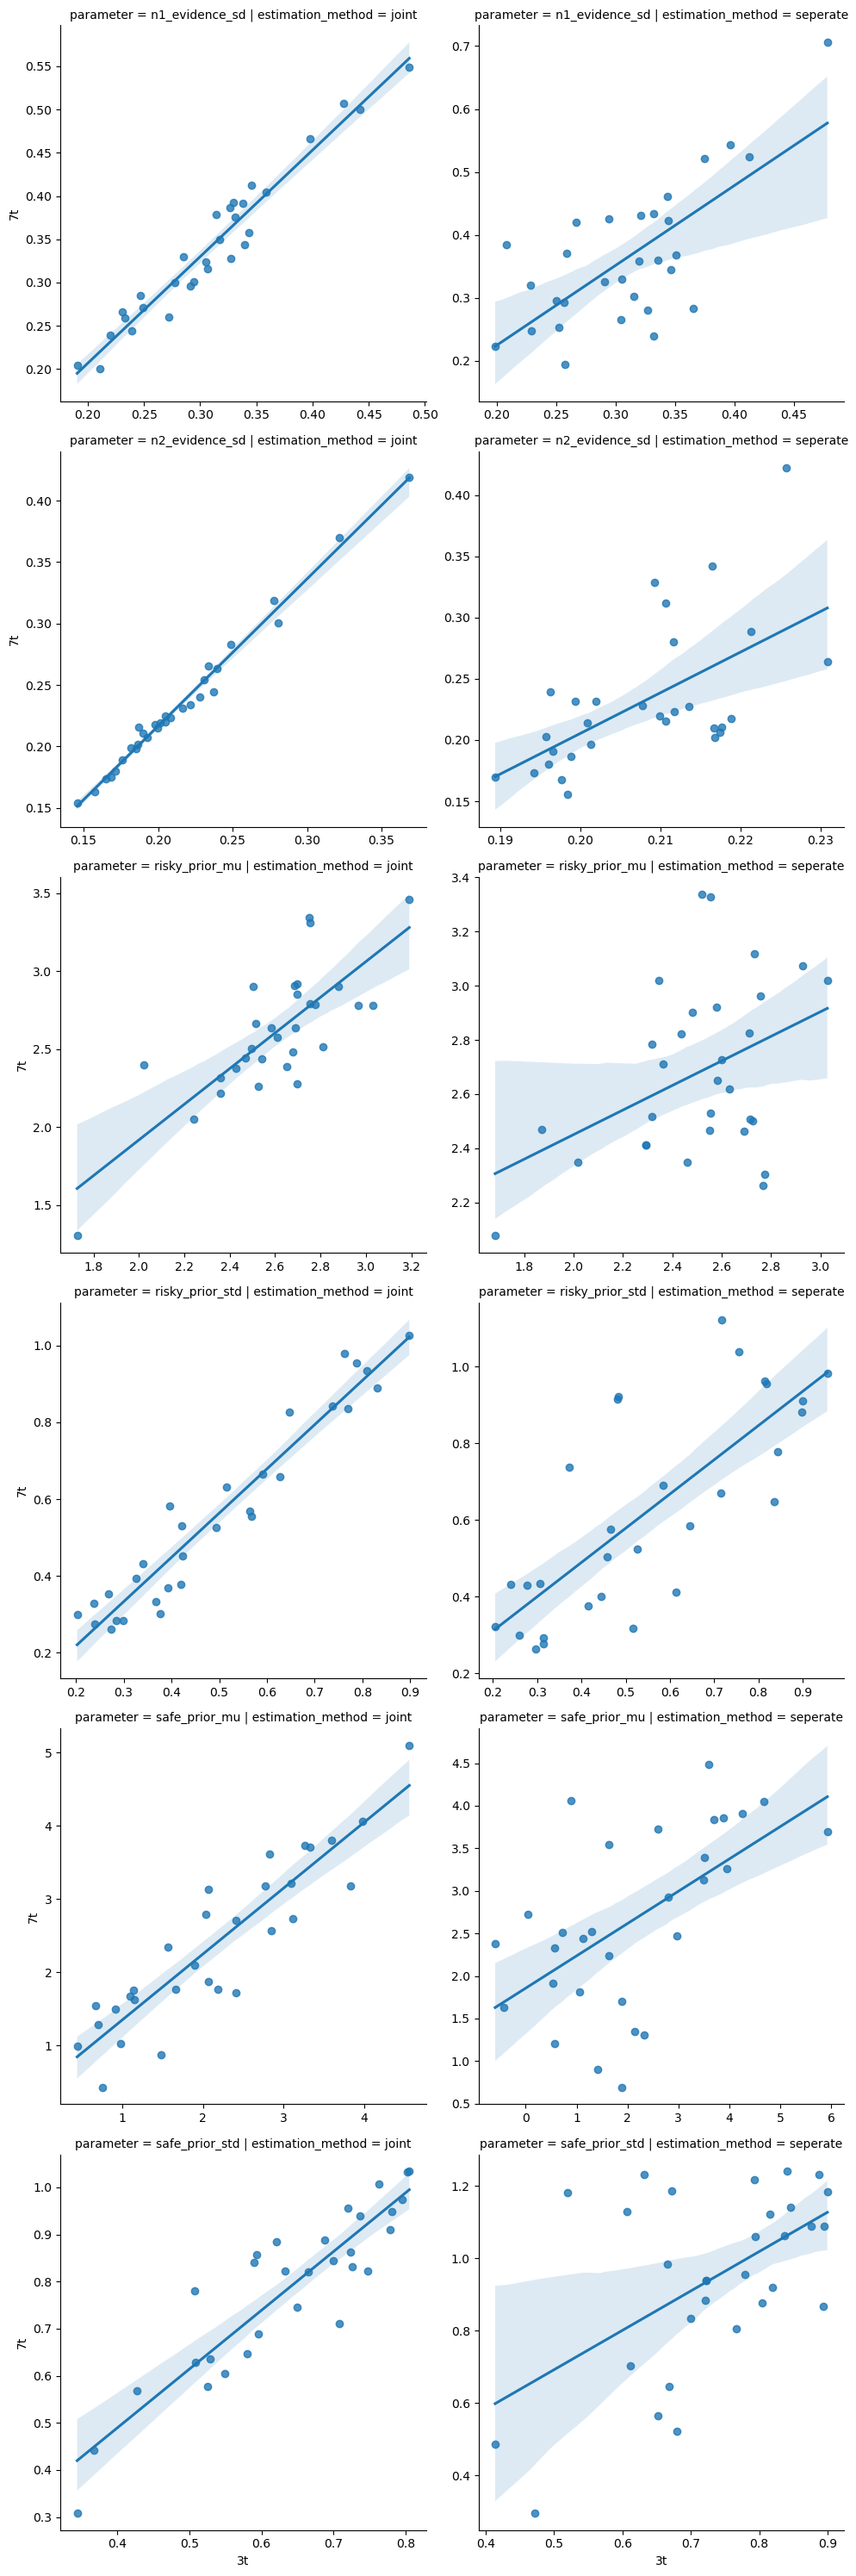

In [159]:
sns.lmplot(x='3t', y='7t', data=est_pars.unstack('session').stack('parameter').reset_index(), col='estimation_method', row='parameter', sharex=False, sharey=False)

In [160]:
gen_pars = est_pars.groupby('subject').mean()

In [161]:
gen_pars

parameter,n1_evidence_sd,n2_evidence_sd,risky_prior_mu,risky_prior_std,safe_prior_mu,safe_prior_std
subject,,,,,,
2,0.289336,0.196522,2.496554,0.884234,1.324674,0.882813
3,0.554739,0.336586,2.995054,0.541915,4.157536,0.673710
4,0.261394,0.212134,2.562287,0.309984,0.873639,0.884208
5,0.468384,0.268881,2.377301,0.517686,3.692440,0.806225
6,0.354851,0.223732,2.189972,0.498595,3.115510,0.822118
7,0.275807,0.207465,2.661134,0.257152,4.594265,0.722379
8,0.343714,0.263568,2.585076,0.522083,3.300205,0.939496
9,0.310048,0.207969,2.610039,0.895088,1.966294,0.830321
10,0.298401,0.185229,2.399366,0.459819,1.498464,0.962704


In [162]:
from risk_experiment.utils import get_all_behavior

In [175]:
df = get_all_behavior(bids_folder='/data/ds-risk')

100%|██████████| 30/30 [00:03<00:00,  9.10it/s]


In [179]:
df.index.unique('subject').dtype

dtype('int64')

In [180]:
gen_pars.index.unique('subject').dtype

dtype('int64')

In [211]:
model = RiskModel(fit_seperate_evidence_sd=True, prior_estimate='full')

simulated_data = model.simulate(df[['n1', 'n2', 'p1', 'p2']].reset_index(), gen_pars, n_samples=1)

simulated_data['risky_first'] = simulated_data['p1'] < simulated_data['p2']
simulated_data['choice'] = simulated_data['simulated_choice']
simulated_data['chose_risky'] = simulated_data['choice'].where(~simulated_data['risky_first'], ~simulated_data['choice'])

simulated_data['n_safe'] = simulated_data['n2'].where(simulated_data['risky_first'], simulated_data['n1'])
simulated_data['n_risky'] = simulated_data['n1'].where(simulated_data['risky_first'], simulated_data['n2'])

simulated_data['log(risky/safe)'] = np.log(simulated_data['n_risky']) - np.log(simulated_data['n_safe'])

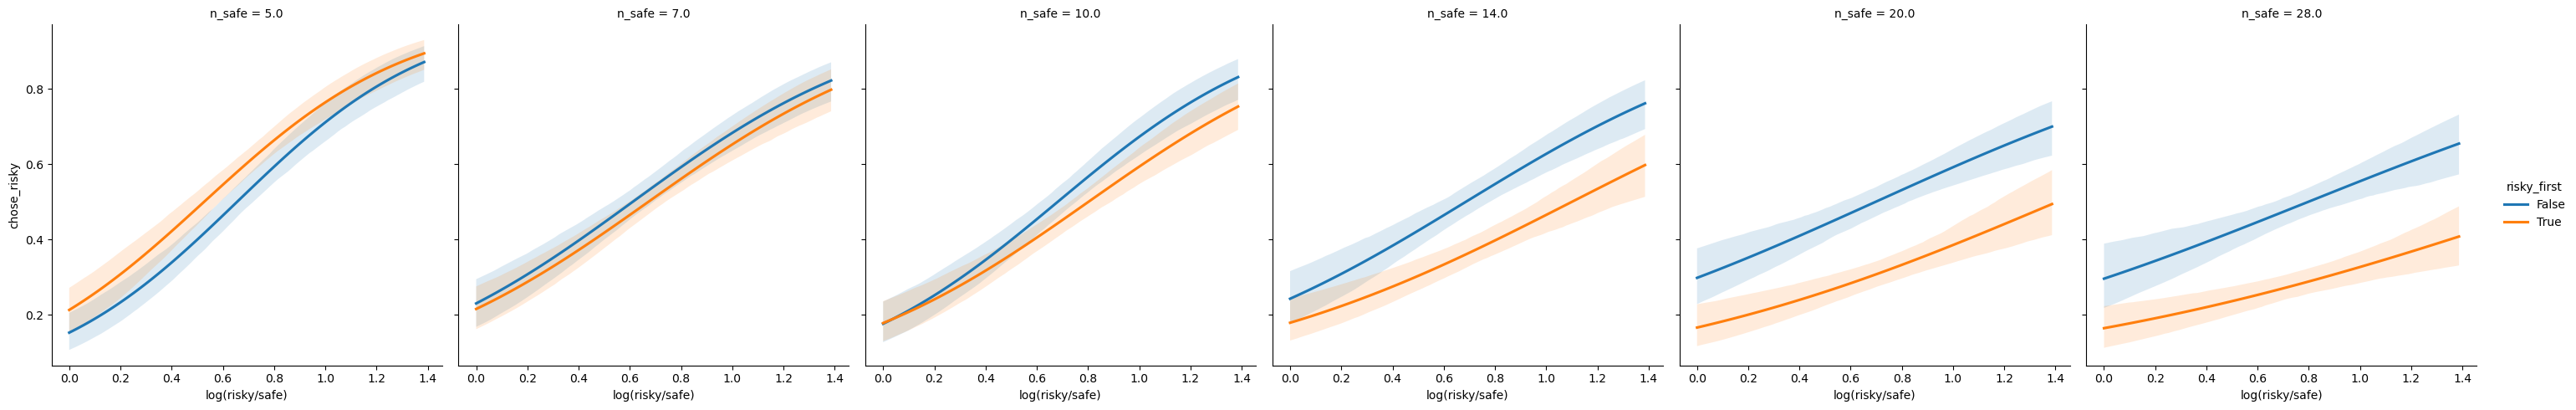

In [214]:
sns.lmplot(x='log(risky/safe)', y='chose_risky', data=simulated_data.groupby(['subject', 'log(risky/safe)', 'risky_first', 'n_safe'])[['chose_risky']].mean().reset_index(), logistic=True,
          hue='risky_first', scatter=False, col='n_safe')

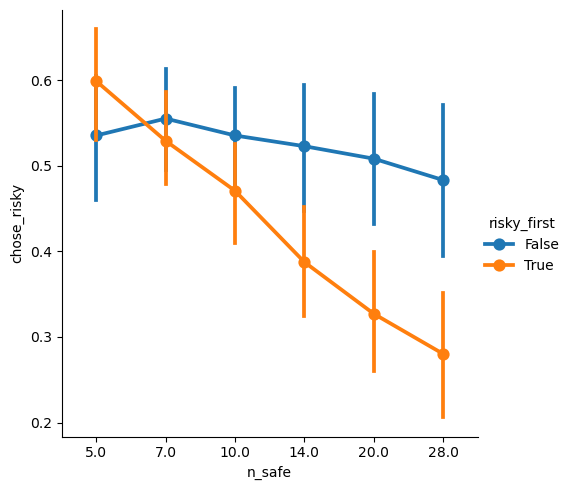

In [213]:
sns.catplot(x='n_safe', y='chose_risky', hue='risky_first', data=simulated_data.groupby(['subject', 'n_safe', 'risky_first'])[['chose_risky']].mean().reset_index(), kind='point')

In [224]:
df = get_all_behavior(bids_folder='/data/ds-risk')

df = df.droplevel(['session', 'run', 'trial_nr'])
df.index = df.index.astype(int)

100%|██████████| 30/30 [00:01<00:00, 22.85it/s]


/var/folders/d4/cpqhwlbn301clph1qk64k01nmjkty3/T/ipykernel_60527/4012033318.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['log(risky/safe)'])


<Axes: xlabel='log(risky/safe)', ylabel='Density'>

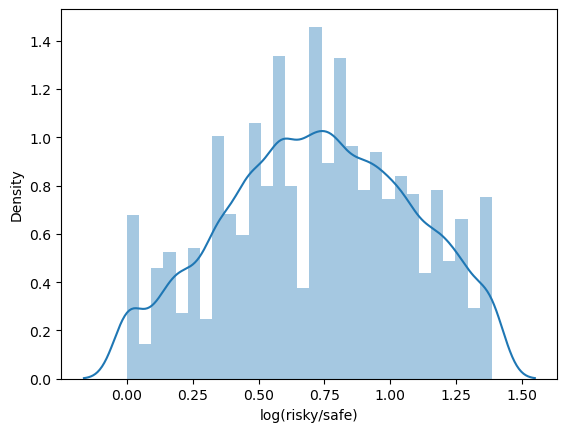

In [217]:
sns.distplot(df['log(risky/safe)'])

Index([ 2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20, 21, 22, 23, 25, 26, 27, 28, 29, 30, 31, 32],
      dtype='int64', name='subject')

In [ ]:
pars = pd.concat((pars_3t, pars_7t, pars_full), keys=['3t', '7t', 'full'], names=['ses'], axis=0)

In [84]:
pars_full

n1_evidence_sd  n2_evidence_sd  risky_prior_mu  \
chain draw subject                                                   
0     0    02            -1.267308       -1.785620        2.282226   
           03            -0.571460       -0.841325        2.535974   
           04            -1.317252       -1.593996        2.424277   
           05            -0.721903       -1.405458        2.549396   
           06            -0.989485       -1.309813        2.259893   
...                            ...             ...             ...   
3     1499 28            -1.429965       -1.731848        2.865663   
           29            -0.737143       -1.244562        2.626059   
           30            -0.538486       -1.410325        2.499924   
           31            -1.173472       -1.453613        2.811144   
           32            -1.026715       -1.410398        2.150235   

                    risky_prior_std  safe_prior_mu  safe_prior_std  
chain draw subject                                                  
0     0    02              0.268232       0.921382       -0.141959  
           03             -1.288021       2.941036       -0.905859  
           04             -1.405062       1.005278       -0.264777  
           05             -0.334733       3.636313       -0.080670  
           06             -0.845663       2.901455       -0.549396  
...                             ...            ...             ...  
3     1499 28              0.102609       2.606406       -0.376354  
           29             -0.524956       2.365927       -0.745091  
           30             -0.424745       1.903010       -0.448928  
           31             -1.146925       3.276984       -0.098733  
           32             -0.997661       2.798645       -0.915781  

[180000 rows x 6 columns]

In [221]:
model.free_parameters.keys()

dict_keys(['n1_evidence_sd', 'n2_evidence_sd', 'risky_prior_mu', 'risky_prior_std', 'safe_prior_mu', 'safe_prior_std'])

In [67]:
idata.posterior['n2_evidence_sd'].to_dataframe()

n2_evidence_sd
chain draw subject n2_evidence_sd_regressors                
0     0    02      Intercept                       -1.785620
                   session[T.7t2]                   0.042682
           03      Intercept                       -0.841325
                   session[T.7t2]                   0.196308
           04      Intercept                       -1.593996
...                                                      ...
3     1499 30      session[T.7t2]                   0.108082
           31      Intercept                       -1.453613
                   session[T.7t2]                  -0.101330
           32      Intercept                       -1.410398
                   session[T.7t2]                  -0.033486

[360000 rows x 1 columns]

In [60]:
idata.posterior['n1_evidence_sd'].to_dataframe()

n1_evidence_sd
chain draw subject                
0     0    02             0.360630
           03             0.936686
           04             0.292727
           05             0.676615
           06             0.615553
...                            ...
3     1499 28             0.152027
           29             0.459061
           30             0.513579
           31             0.191668
           32             0.360574

[180000 rows x 1 columns]

In [61]:
idata.posterior['n2_evidence_sd'].to_dataframe()

n2_evidence_sd
chain draw subject                
0     0    02             0.213412
           03             0.615330
           04             0.236332
           05             0.302468
           06             0.216677
...                            ...
3     1499 28             0.183314
           29             0.317959
           30             0.240740
           31             0.140792
           32             0.246151

[180000 rows x 1 columns]